# Consolidate all files in the various directories into a single data frame

## Setup

In [29]:
import re
from pathlib import Path
from datasets import load_dataset, VerificationMode
from collections import defaultdict
from typing import Any, Literal

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

In [30]:
base = Path(".").resolve() / "eval-all" / "data"
assert base.is_dir() and base.exists()
base

PosixPath('/workspaces/ts-qa/eval-all/data')

## Load the dataset

In [31]:
# Somehow this is necessary
splits = ["train", "val", "test"]
options = dict(verification_mode=VerificationMode.NO_CHECKS)

# Only download these splits
# splits = ["val", "test"]
# options = dict(
#     **options, data_files={split: f"{split}-*" for split in splits},
# )

ds_binary = load_dataset(
    "dasyd/time-qa",
    "binary",
    data_dir="binary",
    **options,
)
ds_multi = load_dataset(
    "dasyd/time-qa",
    "multi",
    data_dir="multi",
    **options,
)
ds_open = load_dataset(
    "dasyd/time-qa",
    "open",
    data_dir="open",
    **options,
)

In [32]:
concat_dataset = (
    pd.concat(
        [
            ds.remove_columns("trajectory").to_pandas()
            for ds_dict in [ds_binary, ds_multi, ds_open]
            for ds in ds_dict.values()
        ],
        ignore_index=True,
    )
    .astype({"sample_id": "int64", "question_id": "int64"})
    .set_index(["sample_id", "question_id"])
    .sort_index()
)
concat_dataset

action_sequence  \
sample_id question_id                                                      
0         0            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          1            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          2            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          3            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          4            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
...                                                                  ...   
29999     0            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          1            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          2            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          3            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          4            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   

                                                     textual_description  \
sample_id question_id                                                      
0         0            The person is starting the sequence with holdi...   
          1            The person is starting the sequence with holdi...   
          2            The person is starting the sequence with holdi...   
          3            The person is starting the sequence with holdi...   
          4            The person is starting the sequence with holdi...   
...                                                                  ...   
29999     0            The sequence starts with picking something up ...   
          1            The sequence starts with picking something up ...   
          2            The sequence starts with picking something up ...   
          3            The sequence starts with picking something up ...   
          4            The sequence starts with picking something up ...   

                                           question_type  \
sample_id question_id                                      
0         0                                   count_open   
          1                            right_after_multi   
          2                                   count_open   
          3             comparison_timestamp_same_binary   
          4                interval_part_sequence_binary   
...                                                  ...   
29999     0                        extremum_least_binary   
          1            comparison_first_last_same_binary   
          2                                 before_multi   
          3                         extremum_most_binary   
          4                                   last_multi   

                                                                question  \
sample_id question_id                                                      
0         0                 How often does the person undertake running?   
          1            What action was undertaken by the person direc...   
          2            What is the number of times the individual has...   
          3            Is the action at 8.174 the same as the action ...   
          4            Did the person perform exactly 2 different act...   
...                                                                  ...   
29999     0            In terms of occurrence, was the person's invol...   
          1            Are the initial and final actions identical to...   
          2            Some time before the person performed playing ...   
          3            Was kicking a ball the most frequently observe...   
          4            Among the activities provided, which one did t...   

                      answer_type  \
sample_id question_id               
0         0                  open   
          1                 multi   
          2                  open   
          3                binary   
          4                binary   
...                           ...   
29999     0  

In [33]:
concat_dataset.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 150000 entries, (0, 0) to (29999, 4)
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   action_sequence      150000 non-null  object 
 1   textual_description  150000 non-null  object 
 2   question_type        150000 non-null  object 
 3   question             150000 non-null  object 
 4   answer_type          150000 non-null  object 
 5   answer_text          150000 non-null  object 
 6   answer               105403 non-null  float64
 7   options              43599 non-null   object 
 8   options_sequence     43599 non-null   object 
dtypes: float64(1), object(8)
memory usage: 12.0+ MB


In [34]:
# 27000, Is it accurate to state that the individual repeats waving 0 times?
concat_dataset.query("sample_id == 27000")

action_sequence  \
sample_id question_id                                                      
27000     0            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          1            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          2            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          3            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          4            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   

                                                     textual_description  \
sample_id question_id                                                      
27000     0            The sequence starts with bowing from 0:0.0 to ...   
          1            The sequence starts with bowing from 0:0.0 to ...   
          2            The sequence starts with bowing from 0:0.0 to ...   
          3            The sequence starts with bowing from 0:0.0 to ...   
          4            The sequence starts with bowing from 0:0.0 to ...   

                                          question_type  \
sample_id question_id                                     
27000     0                            right_after_open   
          1             descriptive_identification_open   
          2            descriptive_identification_multi   
          3                                count_binary   
          4                                  after_open   

                                                                question  \
sample_id question_id                                                      
27000     0            After engaging in bowing, what followed immedi...   
          1              At 2.803, what action is the person performing?   
          2            What is the person doing at 4.354? A: waving, ...   
          3            Is it accurate to state that the individual re...   
          4            Following the performance of bowing by the per...   

                      answer_type  \
sample_id question_id               
27000     0                  open   
          1                  open   
          2                 multi   
          3                binary   
          4                  open   

                                                             answer_text  \
sample_id question_id                                                      
27000     0                                           Someone is waving.   
          1                                        The person is bowing.   
          2                               The correct answer is: waving.   
          3                                                        False   
          4            The subject is waving and picking something up...   

                       answer  \
sample_id question_id           
27000     0               NaN   
          1               NaN   
          2               0.0   
          3               0.0   
          4               NaN   

                                                                 options  \
sample_id question_id                                                      
27000     0                                                          NaN   
          1                                                          NaN   
          2            {'A': 'waving', 'B': 'bowing', 'C': 'picking s...   
          3                                                          NaN   
          4                                                          NaN   

                                                        options_sequence  
sample_id question_id                                                     
27000     0                                                          NaN  
          1                                                          NaN  
          2            [waving, bowing, picking something up with bot...  
          3                                                          NaN  
          4                         

## Load experimental data

In [35]:
def split_compound_id(df: pd.DataFrame) -> pd.DataFrame:
    """Takes a dataframe and splits the 'id' column into 'sample_id' and 'question_id'."""

    df = df.copy()
    original_id = df["id"].astype(str)

    del df["id"]
    df["sample_id"] = original_id.str.slice(0, -1).astype(int)
    df["question_id"] = original_id.str.slice(-1).astype(int)

    return df


# split_compound_id(pd.read_csv(base / "4.2.3" / "llama3.1_fewshot-prompt_test.csv"))

In [36]:
# Keys are (setting/experiment, model, mode)
aggregated: dict[tuple[str, str, str], pd.DataFrame] = dict()

for setting in base.iterdir():
    # setting must start with number dot number (check with regex)
    if not setting.is_dir() or re.match(r"^\d+\.\d+", setting.name) is None:
        print(f"SKIPPING {setting}")
        continue

    for experiment in setting.iterdir():
        if experiment.is_dir():
            print(f"SKIPPING directory {experiment}")
            continue
        if experiment.suffix != ".csv":
            continue

        name = experiment.stem

        # Omit it if it ends like this
        components = name.rsplit("_", 1)
        if components[1] in ("binary", "multi", "open"):
            name = components[0]

        components = name.rsplit("_", 2)
        if len(components) not in (3, 4) or (
            len(components) == 4 and components[3] not in splits
        ):
            print(f"SKIPPING invalid name {name} in '{experiment}'")
            continue

        model, mode, split = components

        # Mode is either "full" or an integer
        try:
            int(mode)
        except ValueError:
            match mode:
                case "full" | "organic":
                    pass
                case "fewshot-prompt":
                    if setting.name in ("4.2.3", "4.2.4"):
                        # Special case for fewshot-prompt in 4.2.3 and 4.2.4
                        mode = 50  # TODO check if correct!
                    else:
                        print(f"SKIPPING special case {mode} in '{experiment}'")
                        continue
                case _:
                    print(f"SKIPPING invalid mode {mode} in '{experiment}'")
                    continue

        assert split in ("val", "test"), f"Invalid split {split} in '{experiment}'"
        if split == "val":
            continue  # We only want test results

        print(f"Setting {setting.name}, model {model}, mode {mode}, split {split}")
        data = pd.read_csv(experiment)
        if "participant_answer" in data.columns:
            data = data.rename(columns={"participant_answer": "prediction_text"})
        assert "prediction_text" in data.columns, (
            f"Missing prediction_text in '{experiment}'"
        )

        if "id" in data.columns:
            data = split_compound_id(data)
        assert "sample_id" in data.columns, f"Missing sample_id in '{experiment}'"
        if "question_id" not in data.columns:
            # Then we try to get if from the sample_id and the question text (almost always unique)
            concat_ds = (
                concat_dataset.reset_index()
                .set_index(["sample_id", "question"])
                .drop(columns="answer_text")
            )
            data = (
                data.reset_index()
                .set_index(["sample_id", "question"])
                .drop(columns="answer")
                .join(concat_ds, how="left")
                .reset_index()
            )
            assert data["question_id"].notna().all(), (
                "Some question_id are missing after join"
            )
        assert "question_id" in data.columns, f"Missing question_id in '{experiment}'"

        assert "answer_text" not in data.columns

        aggregated[(setting.name, model, mode)] = data[
            ["sample_id", "question_id", "prediction_text"]
        ]

SKIPPING /workspaces/ts-qa/eval-all/data/all_joined_judged.h5
Setting 4.2.4, model llama3.1, mode 50, split test
Setting 4.2.1, model gemma2_2b, mode 50, split test
Setting 4.2.1, model falcon, mode 300, split test
Setting 4.2.1, model falcon, mode 450, split test
Setting 4.2.1, model umt5_small, mode 150, split test
Setting 4.2.1, model umt5_small, mode 450, split test
Setting 4.2.1, model llama3.1, mode 350, split test
Setting 4.2.1, model llama3.1, mode 250, split test
Setting 4.2.1, model t5_base, mode 300, split test
Setting 4.2.1, model falcon2, mode 100, split test
Setting 4.2.1, model mvp, mode 50, split test
Setting 4.2.1, model umt5_small, mode 350, split test
Setting 4.2.1, model umt5_base, mode 100, split test
Setting 4.2.1, model mistral, mode 250, split test
Setting 4.2.1, model llama3, mode 350, split test
Setting 4.2.1, model llama2, mode 50, split test
Setting 4.2.1, model gemma2_9b, mode 500, split test
Setting 4.2.1, model gemma2_9b, mode 450, split test
Setting 4.2.

In [37]:
len(aggregated)

188

In [38]:
df = pd.concat(aggregated, verify_integrity=True, copy=False).reset_index(
    level=3, drop=True
)
df.index.names = ["setting", "model", "mode"]
df.reset_index(inplace=True)
df.set_index(["setting", "model", "mode", "sample_id", "question_id"], inplace=True)
df.sort_index(inplace=True)
df.reset_index(inplace=True)
df

,setting,model,mode,sample_id,question_id,prediction_text
0,4.2.1,falcon,100,27000,0,waving
1,4.2.1,falcon,100,27000,1,waving
2,4.2.1,falcon,100,27000,2,waving
3,4.2.1,falcon,100,27000,3,correct
4,4.2.1,falcon,100,27000,4,"waving, picking something up with both hands, ..."
...,...,...,...,...,...,...
2777099,4.4,NeSy Qwen3 (8B) GT,full,29999,0,false
2777100,4.4,NeSy Qwen3 (8B) GT,full,29999,1,false
2777101,4.4,NeSy Qwen3 (8B) GT,full,29999,2,A
2777102,4.4,NeSy Qwen3 (8B) GT,full,29999,3,false


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2777104 entries, 0 to 2777103
Data columns (total 6 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   setting          object
 1   model            object
 2   mode             object
 3   sample_id        int64 
 4   question_id      int64 
 5   prediction_text  object
dtypes: int64(2), object(4)
memory usage: 127.1+ MB


In [40]:
df["setting"].value_counts()

setting
4.2.1    2475000
4.2.2     210000
4.4        60000
4.2.3      15000
4.2.4      15000
4.3         2104
Name: count, dtype: int64

## Join and clean them

In [41]:
joined = df.join(
    concat_dataset, validate="many_to_one", on=["sample_id", "question_id"]
)
joined

,setting,model,mode,sample_id,question_id,prediction_text,action_sequence,textual_description,question_type,question,answer_type,answer_text,answer,options,options_sequence
0,4.2.1,falcon,100,27000,0,waving,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,right_after_open,"After engaging in bowing, what followed immedi...",open,Someone is waving.,NaN,NaN,NaN
1,4.2.1,falcon,100,27000,1,waving,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,descriptive_identification_open,"At 2.803, what action is the person performing?",open,The person is bowing.,NaN,NaN,NaN
2,4.2.1,falcon,100,27000,2,waving,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,descriptive_identification_multi,"What is the person doing at 4.354? A: waving, ...",multi,The correct answer is: waving.,0.0,"{'A': 'waving', 'B': 'bowing', 'C': 'picking s...","[waving, bowing, picking something up with bot..."
3,4.2.1,falcon,100,27000,3,correct,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,count_binary,Is it accurate to state that the individual re...,binary,False,0.0,NaN,NaN
4,4.2.1,falcon,100,27000,4,"waving, picking something up with both hands, ...","{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with bowing from 0:0.0 to ...,after_open,Following the performance of bowing by the per...,open,The subject is waving and picking something up...,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777099,4.4,NeSy Qwen3 (8B) GT,full,29999,0,false,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,extremum_least_binary,"In terms of occurrence, was the person's invol...",binary,True,1.0,NaN,NaN
2777100,4.4,NeSy Qwen3 (8B) GT,full,29999,1,false,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,comparison_first_last_same_binary,Are the initial and final actions identical to...,binary,No,0.0,NaN,NaN
2777101,4.4,NeSy Qwen3 (8B) GT,full,29999,2,A,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,before_multi,Some time before the person performed playing ...,multi,The correct answer is picking something up wit...,0.0,"{'A': 'picking something up with both hands', ...","[picking something up with both hands, jumping..."
2777102,4.4,NeSy Qwen3 (8B) GT,full,29999,3,false,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,extremum_most_binary,Was kicking a ball the most frequently observe...,binary,This is not correct.,0.0,NaN,NaN


In [42]:
joined["model"] = joined["model"].replace(
    {
        "falcon": "Falcon (7B)",
        "falcon2": "Falcon 2 (11B)",
        "gemma_2b": "Gemma (2B)",
        "gemma_7b": "Gemma (7B)",
        "gemma2_2b": "Gemma 2 (2B)",
        "gemma2_9b": "Gemma 2 (9B)",
        "llama2": "Llama 2 (8B)",
        "llama3": "Llama 3 (8B)",
        "llama3.1": "Llama 3.1 (8B)",
        "mistral": "Mistral (7B)",
        "mvp": "MVP",
        "t5_base": "T5 Base",
        "t5_small": "T5 (Small)",
        "umt5_base": "UMT5 (Base)",
        "umt5_small": "UMT5 (Small)",
        "t5-base": "T5 (Base)",
        "t5-small": "T5 (Small)",
        "umt5-base": "UMT5 (Base)",
        "umt5-small": "UMT5 (Small)",
        "human": "Human",
        "human_binary": "Human",
        "human_multi": "Human",
        "human_open": "Human",
    }
)

In [43]:
pd.Series(joined["model"].unique()).sort_values()

0                Falcon (7B)
1             Falcon 2 (11B)
4                 Gemma (2B)
5                 Gemma (7B)
2               Gemma 2 (2B)
3               Gemma 2 (9B)
16                     Human
6               Llama 2 (8B)
7               Llama 3 (8B)
8             Llama 3.1 (8B)
10                       MVP
9               Mistral (7B)
17    NeSy Llama 3.1 (8B) AE
18    NeSy Llama 3.1 (8B) GT
19        NeSy Qwen3 (8B) AE
20        NeSy Qwen3 (8B) GT
15                 T5 (Base)
12                T5 (Small)
11                   T5 Base
13               UMT5 (Base)
14              UMT5 (Small)
dtype: object

In [44]:
joined["answer_type"].value_counts(dropna=False)

answer_type
binary    1132118
open       840156
multi      804830
Name: count, dtype: int64

In [45]:
joined[joined["model"] == "Human"]["answer_type"].value_counts(dropna=False)

answer_type
binary    843
multi     820
open      441
Name: count, dtype: int64

In [46]:
# Cut away potential whitespace and trailing "\n\n#" and following characters from the prediction text
joined["prediction_text"] = (
    joined["prediction_text"]
    .astype(str)
    .str.strip()
    .str.split(r"([\r\n]|\\[rn])+#", n=1, regex=True)
    .str[0]
    .str.strip()
    .str.replace("<0x0A>", "")
    .replace("nan", pd.NA)
)

### Binary

In [47]:
# The ones we were not able to parse are:
joined.loc[
    (joined["answer_type"] == "binary"),
    "prediction_text",
].value_counts(dropna=False)[:50]

prediction_text
false                                              459221
correct                                            333407
<NA>                                               154331
true                                                16699
False                                               12618
-                                                    6006
no                                                   3736
No                                                   3244
Yes                                                  2350
sh the a with                                        2326
sh a the with                                        2177
1                                                    2134
ball                                                 1613
thesh a with                                         1612
false, correct?                                      1609
shaking hands                                        1503
waving                                               140

In [48]:
joined.loc[joined["answer_type"] == "binary", "prediction_parsed_binary"] = (
    joined.loc[joined["answer_type"] == "binary", "prediction_text"]
    .str.lower()
    # find the first "word" (sentence, really):
    .str.split(r"(\\)|\s|[.,]", n=1, regex=True)
    .str[0]
    .map(
        defaultdict(
            lambda: pd.NA,
            {
                "true": True,
                "yes": True,
                "yes.": True,
                "correct": True,
                "false": False,
                "no": False,
                "no.": False,
                "incorrect": False,
                "0": False,
                "1": True,
            },
        )
    )
)

# We parsed:
joined.loc[joined["answer_type"] == "binary", "prediction_parsed_binary"].value_counts(
    dropna=False
)

prediction_parsed_binary
False    496799
True     365637
<NA>     269682
Name: count, dtype: int64

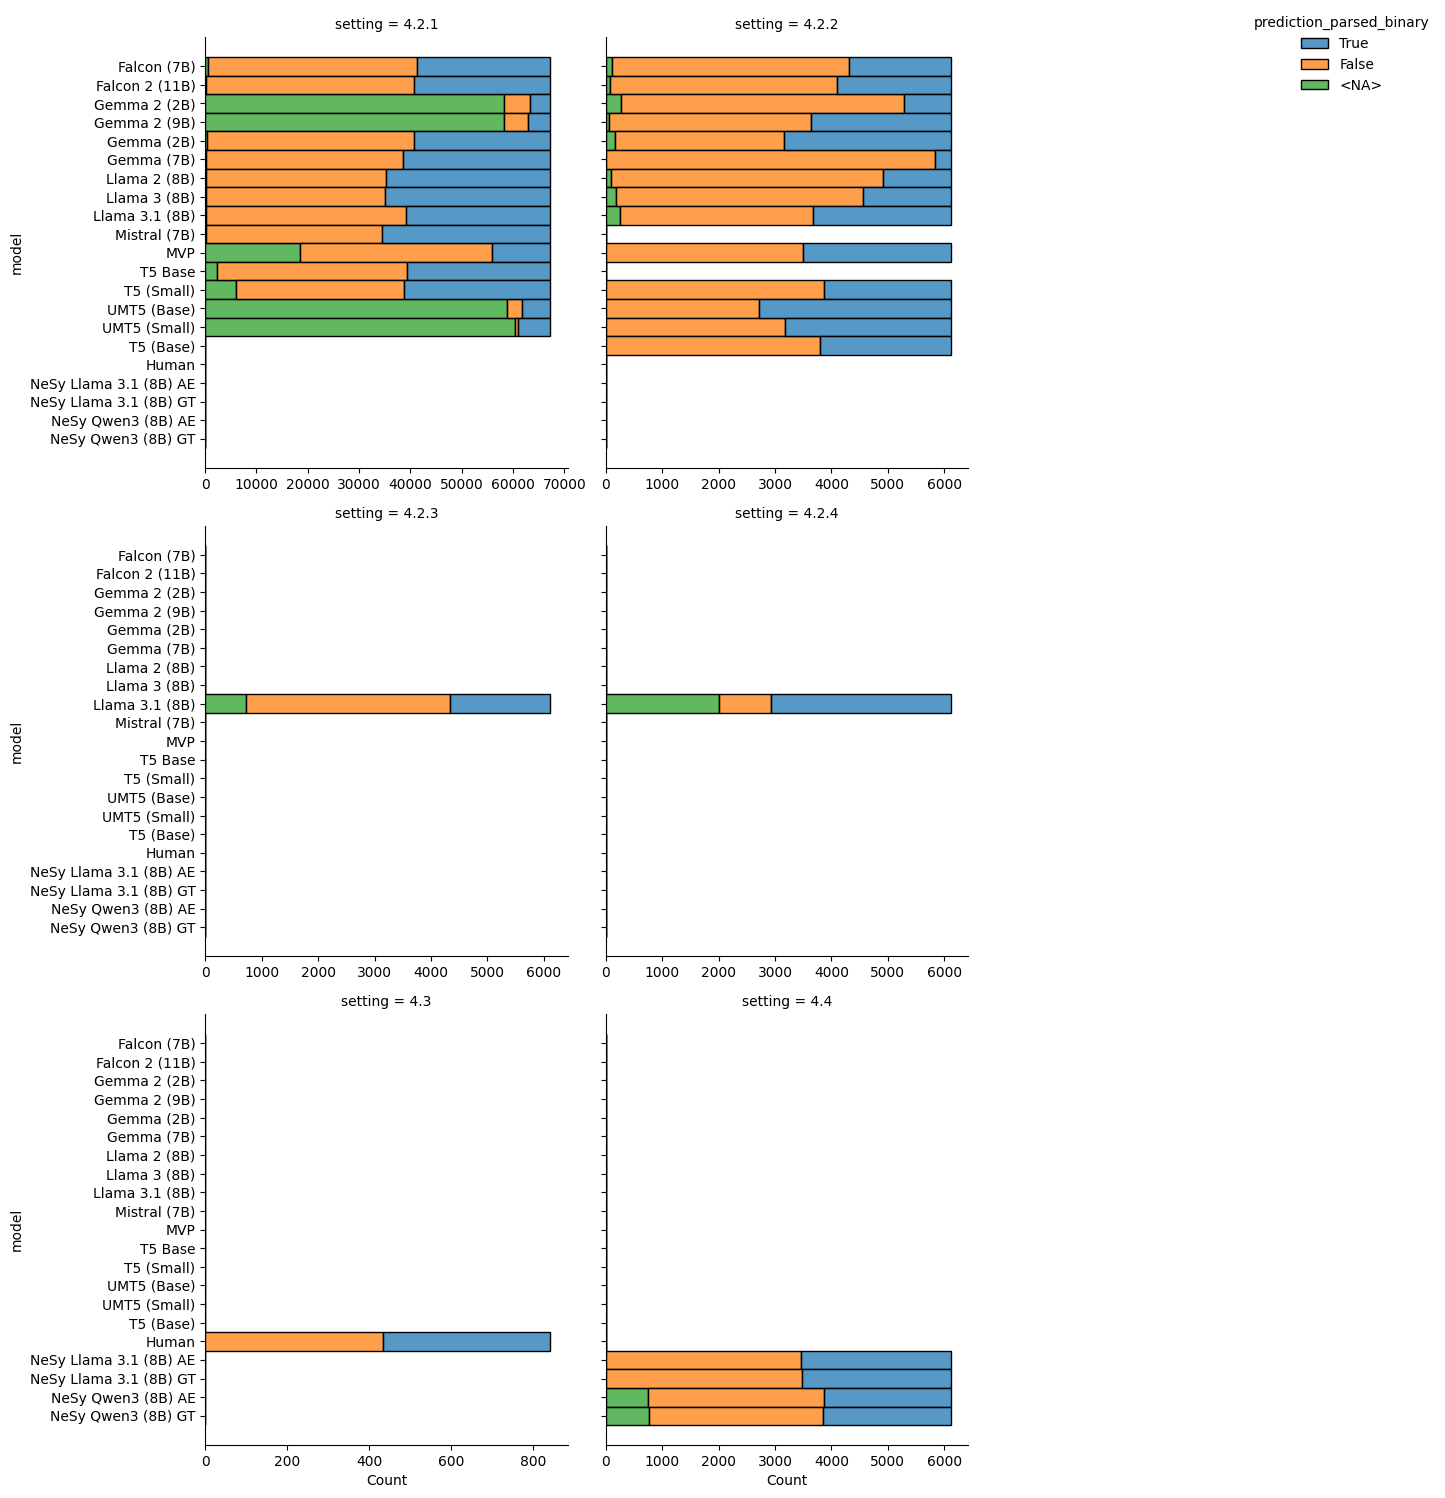

In [49]:
ax = sns.displot(
    data=joined[joined["answer_type"] == "binary"].astype(
        {"prediction_parsed_binary": "str"}
    ),
    y="model",
    col="setting",
    col_wrap=2,
    hue="prediction_parsed_binary",
    multiple="stack",
    facet_kws={"sharex": False},
)
sns.move_legend(ax, bbox_to_anchor=(1.05, 1), loc="upper left")
sns.despine()
pass

In [50]:
# The ones we were not able to parse are:
joined.loc[
    (joined["answer_type"] == "binary") & (joined["prediction_parsed_binary"].isna()),
    "prediction_text",
].value_counts(dropna=False)

prediction_text
<NA>                                                                                                                                                                        154331
-                                                                                                                                                                             6006
sh the a with                                                                                                                                                                 2326
sh a the with                                                                                                                                                                 2177
ball                                                                                                                                                                          1613
                                                                                         

### Multi

In [51]:
joined[joined["answer_type"] == "multi"]["prediction_text"].value_counts(dropna=False)[
    :50
]

prediction_text
<NA>                                    109151
3                                        30314
2                                        28934
shaking hands                            28324
waving                                   27452
1                                        27380
eating with the right hand               26513
drinking with the left hand              26197
catching a ball                          25126
picking something up with both hands     24655
bowing                                   24430
punching                                 24298
golfing (swinging a club)                24069
skipping rope                            24031
dancing                                  23455
sitting down                             21854
playing guitar                           21734
throwing a ball                          21452
jumping once                             21428
kicking a ball                           21138
holding a baby                           209

In [52]:
joined[joined["answer_type"] == "multi"]["options"][:5]

2     {'A': 'waving', 'B': 'bowing', 'C': 'picking s...
6                        {'A': '1', 'B': '2', 'C': '0'}
7     {'A': 'catching a ball', 'B': 'playing guitar'...
9     {'A': 'sitting down', 'B': 'playing guitar', '...
17    {'A': 'eating with the right hand', 'B': 'pick...
Name: options, dtype: object

In [53]:
joined[joined["answer_type"] == "multi"]["prediction_text"]

2                              waving
6                                   1
7                     catching a ball
9          eating with the right hand
17         eating with the right hand
                      ...            
2777093                             C
2777096                             A
2777098                             A
2777101                             A
2777103                             C
Name: prediction_text, Length: 804830, dtype: object

In [54]:
def parse(row: dict[str, Any]) -> str | Literal[pd.NA]:
    if pd.isna(row["prediction_text"]):
        return pd.NA

    value = row["prediction_text"].upper()

    match value:
        case "A" | "B" | "C":
            return value
    # else, we need to parse the options:

    # options are a dict, we want to find the key to the closest value match
    options = row["options"]
    if not options:
        raise ValueError(f"Missing options for {row}")

    # closest_key = min(options, key=lambda k: abs(len(value) - len(options[k])))

    # Now, we use exact matching to get the key
    return next((k for k, v in options.items() if v.upper() == value), pd.NA)


# Derive a new parsed column from each row
joined.loc[joined["answer_type"] == "multi", "prediction_parsed_multi"] = joined[
    joined["answer_type"] == "multi"
].apply(parse, axis="columns")

# We parsed:
joined.loc[joined["answer_type"] == "multi", "prediction_parsed_multi"].value_counts(
    dropna=False
)

prediction_parsed_multi
<NA>    228681
A       200992
B       188250
C       186907
Name: count, dtype: int64

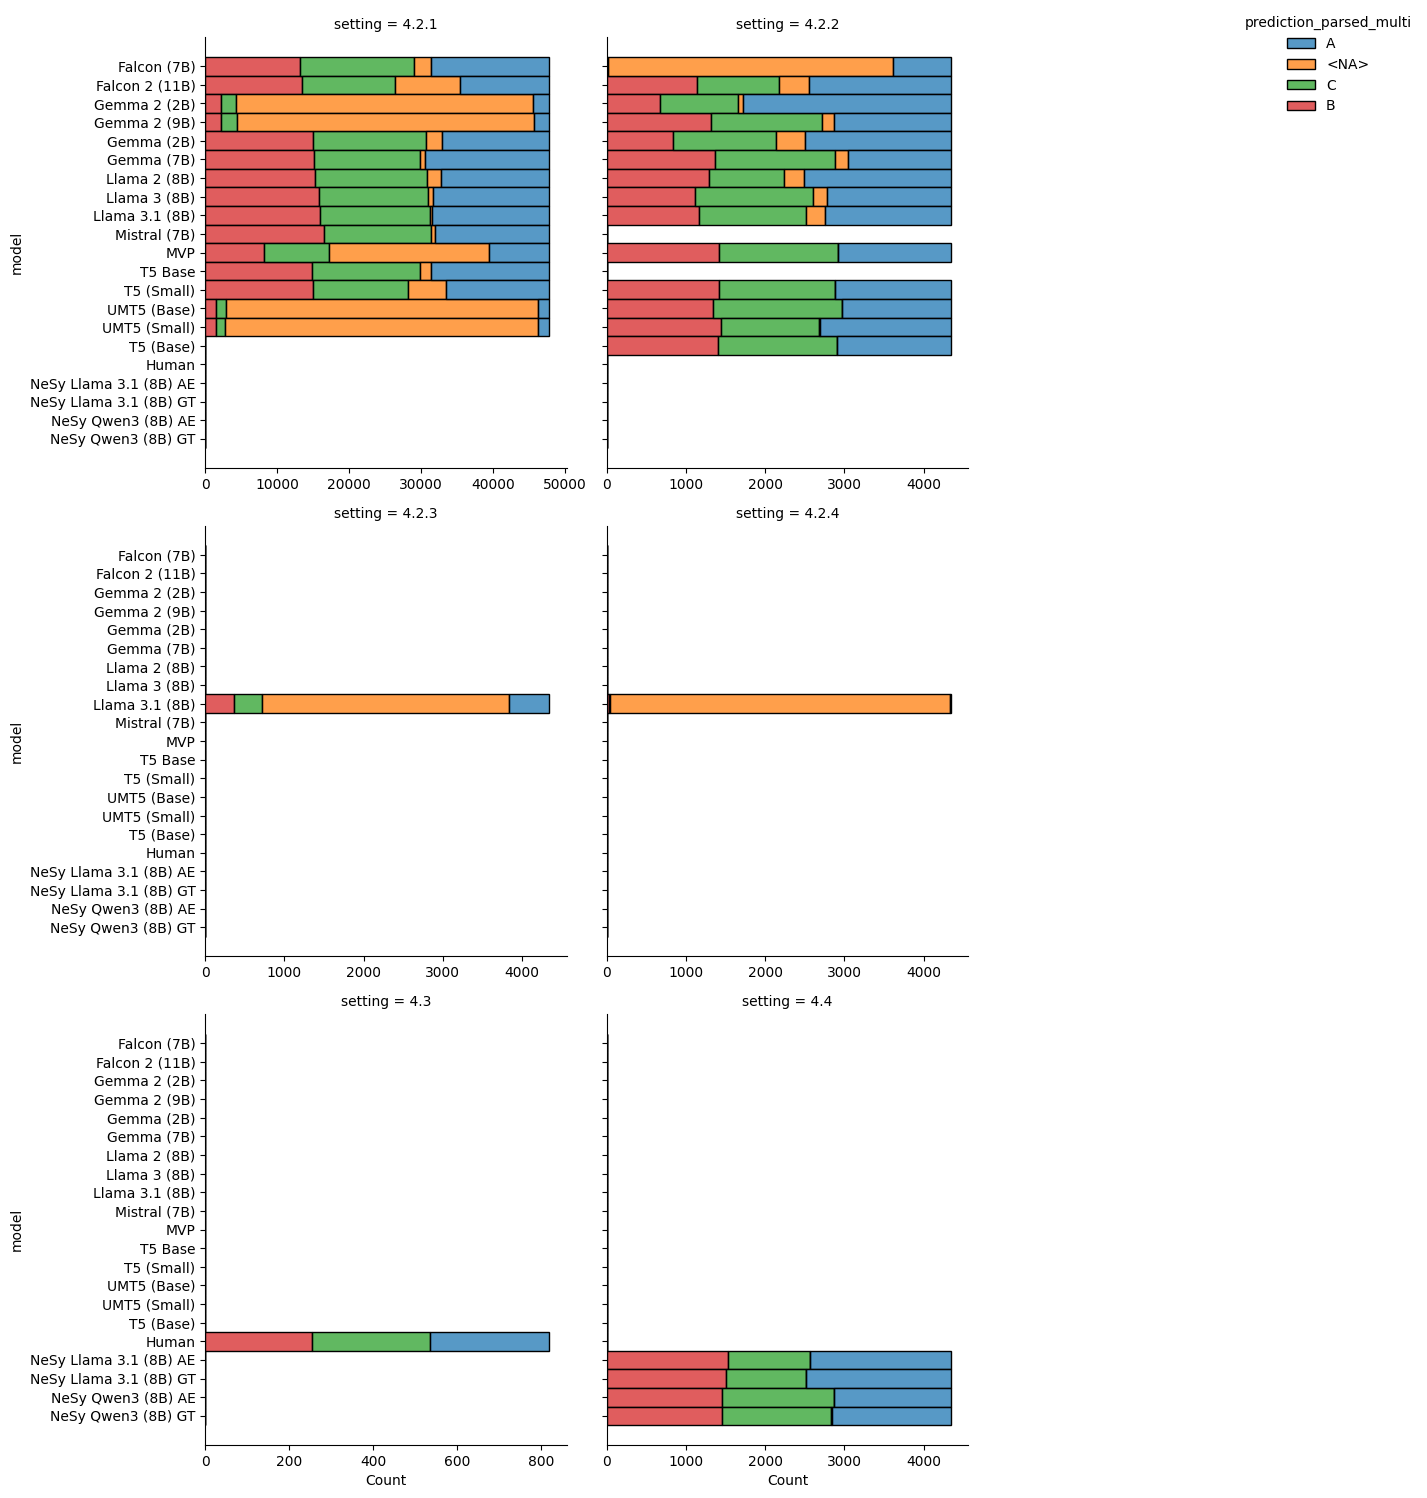

In [55]:
ax = sns.displot(
    data=joined[(joined["answer_type"] == "multi")].astype(
        {"prediction_parsed_multi": "str"}
    ),
    y="model",
    col="setting",
    col_wrap=2,
    hue="prediction_parsed_multi",
    multiple="stack",
    facet_kws={"sharex": False},
)
sns.move_legend(ax, bbox_to_anchor=(1.05, 1), loc="upper left")
sns.despine()
pass

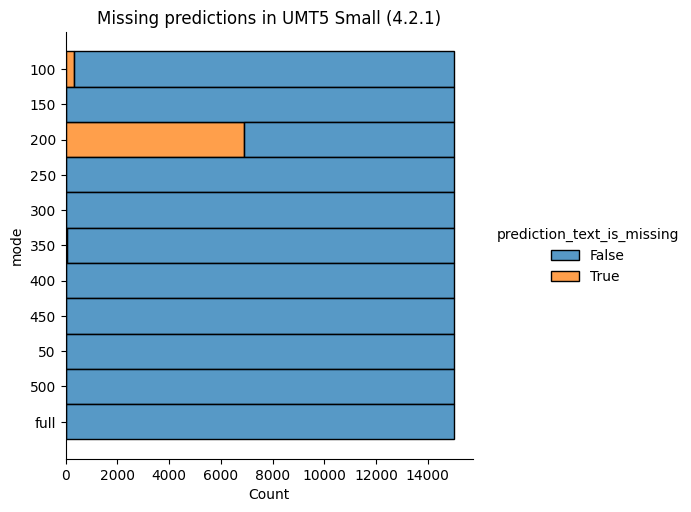

In [57]:
# Check UMT5 Small (4.2.1)

joined_with_missing = joined.copy()
joined_with_missing = joined_with_missing[joined_with_missing["setting"] == "4.2.1"]
joined_with_missing = joined_with_missing[joined_with_missing["model"] == "UMT5 (Small)"]
joined_with_missing["prediction_text_is_missing"] = joined_with_missing[
    "prediction_text"
].isna()

ax = sns.displot(
    data=joined_with_missing.astype({"prediction_text_is_missing": "str"}),
    y="mode",
    hue="prediction_text_is_missing",
    multiple="stack",
)
ax.set(title="Missing predictions in UMT5 Small (4.2.1)")
sns.despine()
pass

In [58]:
# The ones we were not able to parse are:
joined.loc[
    (joined["answer_type"] == "multi") & (joined["prediction_parsed_multi"].isna()),
    "prediction_text",
].value_counts(dropna=False)[:50]

prediction_text
<NA>                                    109151
correct                                   5491
False                                     4349
-                                         4040
sh the a with                             1647
sh a the with                             1507
ball                                      1335
waving                                    1327
0 times                                   1193
thesh a with                              1192
shaking hands                             1162
                                          1105
1 times                                   1093
1                                          948
punching                                   780
hand                                       688
bowing                                     672
throwing a ball                            653
dancing                                    640
the the                                    632
Admission                                  6

### Open

In [59]:
joined.loc[joined["answer_type"] == "open", "prediction_text"].value_counts(
    dropna=False
)[:50]

prediction_text
<NA>                                                                                       115365
1                                                                                           55319
2                                                                                           37371
waving                                                                                      21819
punching                                                                                    21498
bowing                                                                                      20283
skipping rope                                                                               20102
shaking hands                                                                               19872
kicking a ball                                                                              19318
3                                                                                           19232
danc

In [60]:
joined.loc[joined["answer_type"] == "open", "prediction_text"] = (
    joined.loc[joined["answer_type"] == "open", "prediction_text"]
    # Replace everything that only consists of whitespace, punctuation, or is empty with pd.NA
    .replace(r"^[^a-zA-Z0-9]*$", pd.NA, regex=True)
    .replace("<NA>", pd.NA)
)

In [61]:
joined.loc[joined["answer_type"] == "open", "prediction_text"].value_counts(
    dropna=False
)[:50]

prediction_text
<NA>                                                                                       122196
1                                                                                           55319
2                                                                                           37371
waving                                                                                      21819
punching                                                                                    21498
bowing                                                                                      20283
skipping rope                                                                               20102
shaking hands                                                                               19872
kicking a ball                                                                              19318
3                                                                                           19232
danc

# Filter for important ones

Gemma 2, MVP, and UTM5 were so bad, that we exclude them from any further analysis.

In [62]:
# Gemma 2, MVP, and UTM5 were so bad, that we exclude them from any further analysis.
size_before = len(joined)
joined = joined[
    ~joined["model"].isin(
        ["Gemma 2 (2B)", "Gemma 2 (9B)", "MVP", "UMT5 Small", "UMT5 Base"]
    )
]
print(
    f"Removed {size_before - len(joined)} rows ({size_before} -> {len(joined)}; {(size_before - len(joined)) / size_before:.2%}%)"
)

Removed 540000 rows (2777104 -> 2237104; 19.44%%)


/tmp/ipykernel_24921/2082826652.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


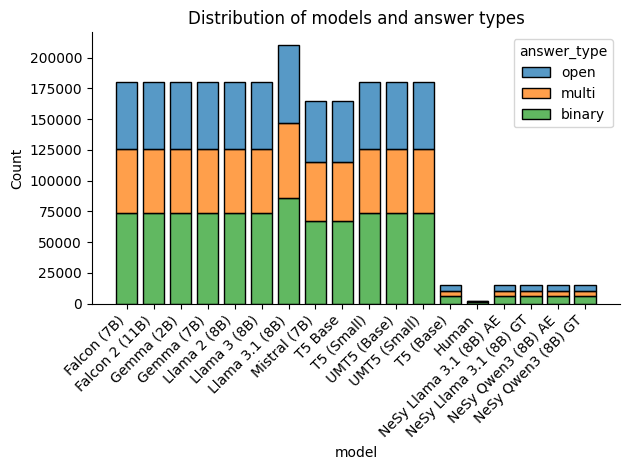

In [63]:
# Show a histogram over models
ax = sns.histplot(
    data=joined,
    x="model",
    hue="answer_type",
    multiple="stack",
    shrink=0.8,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set(title="Distribution of models and answer types")
sns.despine()
plt.tight_layout()
plt.show()

# Store them

In [64]:
joined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2237104 entries, 0 to 2777103
Data columns (total 17 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   setting                   object 
 1   model                     object 
 2   mode                      object 
 3   sample_id                 int64  
 4   question_id               int64  
 5   prediction_text           object 
 6   action_sequence           object 
 7   textual_description       object 
 8   question_type             object 
 9   question                  object 
 10  answer_type               object 
 11  answer_text               object 
 12  answer                    float64
 13  options                   object 
 14  options_sequence          object 
 15  prediction_parsed_binary  object 
 16  prediction_parsed_multi   object 
dtypes: float64(1), int64(2), object(14)
memory usage: 307.2+ MB


In [65]:
# There should be no duplicates at all, let's check that
assert not joined.duplicated(
    ["setting", "model", "mode", "sample_id", "question_id"]
).any()

In [66]:
# joined.to_parquet(base / "all_joined.parquet")  # Somehow gave an error
joined.to_hdf(base / "all_joined.h5", key="data", mode="w")

/tmp/ipykernel_24921/2291109138.py:2: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block2_values] [items->Index(['setting', 'model', 'mode', 'prediction_text', 'action_sequence',
       'textual_description', 'question_type', 'question', 'answer_type',
       'answer_text', 'options', 'options_sequence',
       'prediction_parsed_binary', 'prediction_parsed_multi'],
      dtype='object')]

  joined.to_hdf(base / "all_joined.h5", key="data", mode="w")


In [67]:
!ls -sh {base / "all_joined.h5"}

241M /workspaces/ts-qa/eval-all/data/all_joined.h5
